Why Random Forest Beats Decision Tree

Decision Tree:

High Variance
Overfits Easily


Random Forest:

Less Variance
Less Overfitting
More Stable
Higher Accuracy

Random Forest Project: Loan Approval Prediction
Business Problem

A bank wants to predict whether a loan application should be:

0 = Rejected
1 = Approved

Features:

Age
AnnualIncome
CreditScore
EmploymentYears
ExistingLoans
LoanAmount

Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

Cell 2: Generate Realistic Dataset

In [2]:
np.random.seed(42)

n = 5000

age = np.random.randint(21, 65, n)

annual_income = np.random.randint(20000, 200000, n)

credit_score = np.random.randint(300, 850, n)

employment_years = np.random.randint(0, 30, n)

existing_loans = np.random.randint(0, 6, n)

loan_amount = np.random.randint(5000, 100000, n)

loan_approved = (
    (annual_income > 60000).astype(int)
    + (credit_score > 650).astype(int)
    + (employment_years > 2).astype(int)
    - (existing_loans > 3).astype(int)
)

loan_approved = (loan_approved >= 2).astype(int)

df = pd.DataFrame({
    "Age": age,
    "AnnualIncome": annual_income,
    "CreditScore": credit_score,
    "EmploymentYears": employment_years,
    "ExistingLoans": existing_loans,
    "LoanAmount": loan_amount,
    "LoanApproved": loan_approved
})

df

,Age,AnnualIncome,CreditScore,EmploymentYears,ExistingLoans,LoanAmount,LoanApproved
0,59,48054,348,26,4,60186,0
1,49,196469,615,7,0,47346,1
2,35,33233,712,21,5,10230,0
3,63,176140,733,20,3,30720,1
4,28,85727,301,28,4,48023,0
...,...,...,...,...,...,...,...
4995,53,70903,775,6,2,37259,1
4996,52,85792,552,25,2,26450,1
4997,49,53439,371,12,4,61949,0
4998,41,184329,522,15,3,41929,1


EDA

In [11]:
print(df.shape)
print(df.info(),"\n",df.describe(),"\n",df["LoanApproved"].value_counts())

(5000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              5000 non-null   int64
 1   AnnualIncome     5000 non-null   int64
 2   CreditScore      5000 non-null   int64
 3   EmploymentYears  5000 non-null   int64
 4   ExistingLoans    5000 non-null   int64
 5   LoanAmount       5000 non-null   int64
 6   LoanApproved     5000 non-null   int64
dtypes: int64(7)
memory usage: 273.6 KB
None 
                Age   AnnualIncome  CreditScore  EmploymentYears  \
count  5000.000000    5000.000000  5000.000000        5000.0000   
mean     42.575000  109920.089400   575.349400          14.4352   
std      12.554597   51849.700493   160.064118           8.5749   
min      21.000000   20028.000000   300.000000           0.0000   
25%      32.000000   64873.250000   438.750000           7.0000   
50%      43.000000  109829.500000   574.000000    

Cell 4: Target Distribution

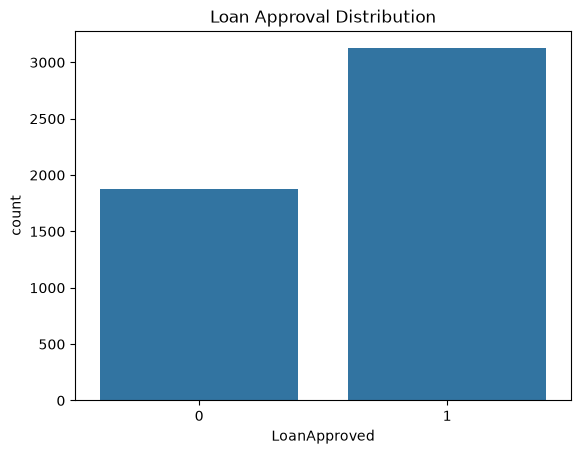

In [12]:
sns.countplot(
    x="LoanApproved",
    data=df
)

plt.title("Loan Approval Distribution")
plt.show()

Cell 5: Correlation Heatmap

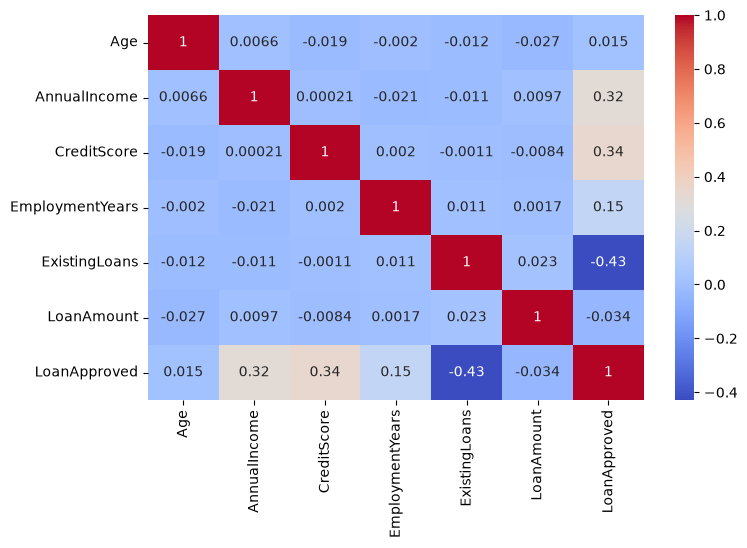

In [15]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Cell 6: Features and Target

In [16]:
X = df.drop("LoanApproved", axis=1)

y = df["LoanApproved"]

Cell 7: Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Cell 8: Train Random Forest

In [18]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Cell 9: Predictions

In [19]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

Cell 10: Evaluation

In [20]:
print("Accuracy :",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall   :",
      recall_score(y_test, y_pred))

print("F1 Score :",
      f1_score(y_test, y_pred))

Accuracy : 0.999
Precision: 1.0
Recall   : 0.9984
F1 Score : 0.9991993594875901


Cell 11: Confusion Matrix

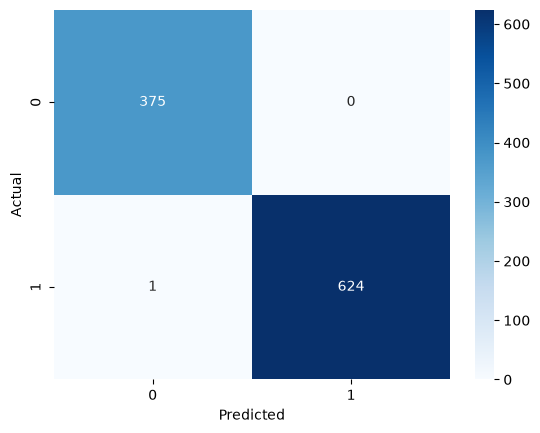

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Cell 12: Classification Report

In [22]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       375
           1       1.00      1.00      1.00       625

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



Cell 13: Feature Importance

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

           Feature  Importance
4    ExistingLoans    0.341036
2      CreditScore    0.272076
1     AnnualIncome    0.242723
3  EmploymentYears    0.120587
5       LoanAmount    0.013630
0              Age    0.009947


visualization

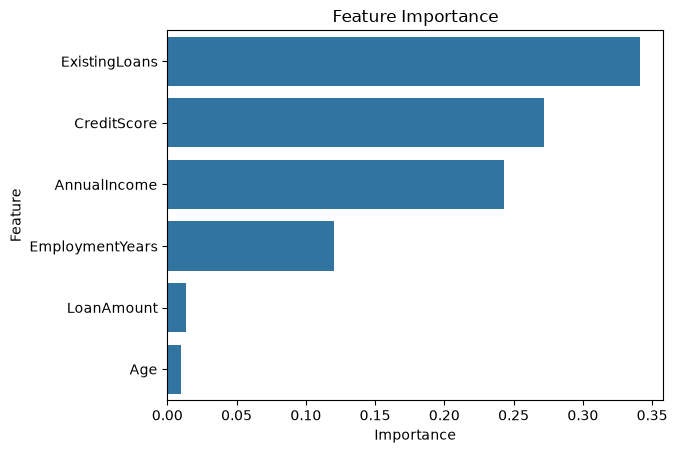

In [24]:
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

Cell 14: Hyperparameter Tuning

In [25]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


Cell 15: Best Model

In [26]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(
    X_test
)

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       375
           1       1.00      1.00      1.00       625

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



Cell 16: Train vs Test Score

In [27]:
print(
    "Train Score:",
    best_rf.score(
        X_train,
        y_train
    )
)

print(
    "Test Score:",
    best_rf.score(
        X_test,
        y_test
    )
)

Train Score: 1.0
Test Score: 0.998


Cell 17: Predict New Applicant

In [28]:
new_applicant = pd.DataFrame({
    "Age": [35],
    "AnnualIncome": [85000],
    "CreditScore": [720],
    "EmploymentYears": [8],
    "ExistingLoans": [1],
    "LoanAmount": [25000]
})

prediction = best_rf.predict(
    new_applicant
)

probability = best_rf.predict_proba(
    new_applicant
)

print("Prediction:", prediction[0])

print("Probability:", probability[0])

Prediction: 1
Probability: [0. 1.]
